In [2]:
import pandas as pd
import numpy as np
import yfinance as yfin
import ta

In [3]:
df = yfin.download("BTC-USD", start="2020-01-01", end="2026-01-01")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095
...,...,...,...,...,...
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929


In [4]:
df.columns = df.columns.droplevel(1)

In [5]:
# EMAs
df['EMA_5'] = ta.trend.ema_indicator(close=df['Close'], window=5, fillna=True) / df['Close']
df['EMA_20'] = ta.trend.ema_indicator(close=df['Close'], window=20, fillna=True) / df['Close']
df['EMA_50'] = ta.trend.ema_indicator(close=df['Close'], window=50, fillna=True) / df['Close']
df['EMA_100'] = ta.trend.ema_indicator(close=df['Close'], window=100, fillna=True) / df['Close']

# índice de fuerza relativa
df['RSI'] = ta.momentum.rsi(close=df['Close'], fillna=True)

# rango verdadero medio
df['ATR'] = ta.volatility.average_true_range(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    fillna=True
)

# rango de porcentaje de Williams
df['Williams'] = ta.momentum.williams_r(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    fillna=True
)
df

Price,Close,High,Low,Open,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,Williams
Date,,,,,,,,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,1.000000,1.000000,1.000000,1.000000,100.000000,0.000000,-68.218694
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,1.020491,1.027809,1.029530,1.030127,0.000000,0.000000,-84.266248
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.980369,0.979655,0.979969,0.980121,64.320963,0.000000,-13.801564
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.981112,0.973726,0.972398,0.971988,68.334871,0.000000,-3.264899
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.987350,0.976150,0.973397,0.972457,68.373359,0.000000,-21.156391
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,0.997804,1.008144,1.053045,1.117371,44.616331,2800.162979,-44.509460
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,0.998281,1.007019,1.050577,1.114627,44.754060,2642.432587,-43.954204
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849,1.004183,1.013646,1.056676,1.121105,42.401671,2709.490416,-55.456666


In [7]:
cl = np.array(df['Close'])
target = np.where(cl[1:] > cl[:-1], 1, -1)

df.drop(df.tail(1).index, inplace=True)


df['Target'] = target
df


Price,Close,High,Low,Open,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,Williams,Target
Date,,,,,,,,,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,1.000000,1.000000,1.000000,1.000000,100.000000,0.000000,-68.218694,-1
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,1.020491,1.027809,1.029530,1.030127,0.000000,0.000000,-84.266248,1
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.980369,0.979655,0.979969,0.980121,64.320963,0.000000,-13.801564,1
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.981112,0.973726,0.972398,0.971988,68.334871,0.000000,-3.264899,1
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.987350,0.976150,0.973397,0.972457,68.373359,0.000000,-21.156391,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,87301.429688,89459.429688,86628.140625,87235.507812,42455674908,1.002423,1.014789,1.061263,1.126164,42.642249,2962.344386,-53.872190,1
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,0.997804,1.008144,1.053045,1.117371,44.616331,2800.162979,-44.509460,1
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,0.998281,1.007019,1.050577,1.114627,44.754060,2642.432587,-43.954204,-1


In [8]:
df.drop(df.head(29).index, inplace=True)
df

Price,Close,High,Low,Open,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,Williams,Target
Date,,,,,,,,,,,,,
2020-01-30,9508.993164,9553.125977,9230.897461,9316.016602,32378792851,0.966551,0.912616,0.855690,0.816590,73.875865,285.487839,-3.431029,-1
2020-01-31,9350.529297,9521.706055,9230.776367,9508.313477,29432489719,0.988621,0.934931,0.875282,0.833786,68.660698,285.876542,-15.750526,1
2020-02-01,9392.875000,9439.323242,9313.239258,9346.357422,25922656496,0.989443,0.937315,0.876381,0.833393,69.284697,274.462788,-12.458433,-1
2020-02-02,9344.365234,9468.797852,9217.824219,9389.820312,30835736946,0.996386,0.947687,0.885600,0.840933,67.623590,272.784991,-16.229740,-1
2020-02-03,9293.521484,9540.372070,9248.633789,9344.683594,30934096509,1.001225,0.957360,0.894742,0.848593,65.841806,274.138798,-20.182499,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,87301.429688,89459.429688,86628.140625,87235.507812,42455674908,1.002423,1.014789,1.061263,1.126164,42.642249,2962.344386,-53.872190,1
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,0.997804,1.008144,1.053045,1.117371,44.616331,2800.162979,-44.509460,1
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,0.998281,1.007019,1.050577,1.114627,44.754060,2642.432587,-43.954204,-1


In [9]:
x = np.array(df.iloc [:,5:-1])
y = np.array(df['Target'])

print(x.shape)
print(y.shape)


(2162, 7)
(2162,)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

from sklearn.svm import SVC


In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)

print(x_train.shape)
print(x_test.shape)



(1945, 7)
(217, 7)


In [15]:
ss = StandardScaler()
ss = ss.fit(x_train)

x_train = ss.transform(x_train)
x_test = ss.transform(x_test)


In [17]:
#suport vector machine
svc = SVC()
svc = svc.fit(x_train, y_train)


In [21]:
svc_pred = svc.predict(x_test)
accuracy_score(y_test, svc_pred)

0.5023041474654378

In [22]:
confusion_matrix(y_test, svc_pred)

array([[65, 45],
       [63, 44]])

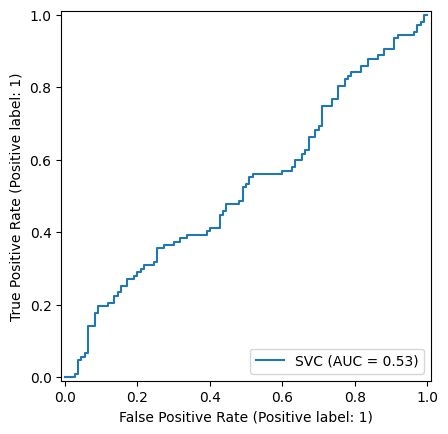

In [25]:
RocCurveDisplay.from_estimator(svc, x_test, y_test)